# **Recitation 4: Retrieval Augmented Generation (RAG) for MIT Courses**

* V1.0 - Spring 2025 - Evan Yao, Adapted from Lecture 10 Colab Notebook.
* V2.0 - Spring 2026 - Rama Ramakrishnan

# Setup

Let's get started by installing the openai python package and `tiktoken`, a package that can tokenize inputs using BPE, in a manner compatible with the OpenAI models. The setup here is the same as that of Lecture 10. We need to go to the "Secret" tab of colab (on the left sidebar) and add "OPENAI_API_KEY" as the name and the corresponding value that you copied from OpenAI's website. You then need to allow the key notebook access.


In [ ]:
!pip install --upgrade openai
!pip install tiktoken

from bs4 import BeautifulSoup
import requests
import re

import numpy as np

import pandas as pd
pd.set_option('display.max_colwidth', 400)
import tiktoken
import os
from google.colab import userdata, drive

# models
EMBEDDING_MODEL = "text-embedding-3-small"
GPT_MODEL = "gpt-4o-mini"


os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

# client for OpenAI API
from openai import OpenAI # for calling the OpenAI API
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", "<your OpenAI API key if not set as env var>"))

In [ ]:
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY", "<your OpenAI API key if not set as env var>"))

# Prompting without custom data

Before we try anything fancy, let's simply ask the LLM a question on MIT Sloan's courses. Recall from class the syntax that we used to query OpenAI's API.

In [ ]:
query = 'Question: Who are the instructors of Hands-On Deep Learning?'
# query = 'Who are the instructors of Hands-On Deep Learning?. Give me an answer or say I dont know'

response = client.chat.completions.create(
    messages=[
        {'role': 'system', 'content': 'You answer questions about courses at the MIT Sloan School of Management.'},
        {'role': 'user', 'content': query},
    ],
    model=GPT_MODEL,
    temperature=0,
)

print(response.choices[0].message.content)

The course "Hands-On Deep Learning" at MIT Sloan is typically taught by a team of instructors, including faculty members with expertise in artificial intelligence and machine learning. As of my last update, the course was co-taught by Professor Devavrat Shah and Professor Anastasios Doulamis. However, it's always a good idea to check the latest course listings on the MIT Sloan website for the most current information regarding instructors and course details.


The LLM is unable to answer this question correctly, possibly because the exact MIT course catalog page for HODL may not have been part of the pretraining data for the model.


---



Note that the first message, with `'role': 'system'` is how we set the behavior/tone of the assistant by providing an instruction before any dialogue. See the following quote from OpenAI's API:

> Typically, a conversation is formatted with a system message first, followed by alternating user and assistant messages. The system message helps set the behavior of the assistant. For example, you can modify the personality of the assistant or provide specific instructions about how it should behave throughout the conversation. However note that the system message is optional and the model’s behavior without a system message is likely to be similar to using a generic message such as "You are a helpful assistant."

In [ ]:
query = 'What course should I take if I want to learn more about deep learning? Please give me the course number.'

response = client.chat.completions.create(
    messages=[
        {'role': 'system', 'content': 'You answer questions about courses at the MIT Sloan School of Management.'},
        {'role': 'user', 'content': query},
    ],
    model=GPT_MODEL,
    temperature=0,
)

print(response.choices[0].message.content)

At MIT Sloan, you might be interested in the course "Artificial Intelligence: Implications for Business Strategy" (course number 15.871). While it covers a broader range of AI topics, it includes discussions on deep learning and its applications in business. For a more technical focus specifically on deep learning, you may want to look into courses offered by the Electrical Engineering and Computer Science department, such as "Deep Learning for Self-Driving Cars" (6.864) or "Machine Learning" (6.036). However, these may not be part of the Sloan curriculum directly. Always check the latest course offerings for the most accurate information.


Notice how the LLM made up a course that sounds like it exists, but doesn't. 15.871 is actually "Introduction to Systems Dynamics"!

# Scraping the MIT Course Catalog

We will scrape the MIT course catalog for Course 15. There are 3 pages at the following links:

* Page 1 (https://student.mit.edu/catalog/m15a.html)
* Page 2 (https://student.mit.edu/catalog/m15b.html)
* Page 3 (https://student.mit.edu/catalog/m15c.html)

The code below will scrape the HTML, and extract the course name and description for each course.

In [ ]:
def parse_mit_course_catlog(url):
    response = requests.get(url)

    soup = BeautifulSoup(response.text, "html.parser")
    blocks = []

    for heading in soup.find_all("h3"):  # find separators, in this case h3 nodes

        ## Content that appears as plain text (not enclosed in HTML tags)
        string_values = ""
        for sibling in heading.find_next_siblings(string=True):
            if sibling.name == "h3":
                break
            string_values += sibling.text.strip() + " "

        ## Content that is in HTML tags (e.g. Fall/Spring/IAP, Graduate/Undergraduate, Instructor)
        tag_info = ""
        for sibling in heading.find_next_siblings():
            if sibling.name == "h3":
                break
            if sibling.name == 'img' and sibling.get('height') == '16':
                tag_info += sibling.get('title') + " "

            # Italics text include meeting time (MW8:30-10), instructor
            if sibling.name == 'i':
                tag_info += sibling.text.strip() + " "

        blocks.append({'course_name': heading.text.strip(), 'description': tag_info + " " + string_values})

    return pd.DataFrame(blocks)

urls = [
    "https://student.mit.edu/catalog/m15a.html",
    "https://student.mit.edu/catalog/m15b.html",
    "https://student.mit.edu/catalog/m15c.html",
]

mit_course_data = []

for url in urls:
    mit_course_data.append(parse_mit_course_catlog(url))

mit_course_data = pd.concat(mit_course_data).reset_index(drop=True)
mit_course_data

,course_name,description
0,15.000 Explorations in Management,"Undergrad Fall J. Orlin ( ) Prereq: None Units: 2-0-1 [P/D/F] Broad introduction to the various aspects of management including analytics, accounting and finance, operations, marketing, entrepreneurship and leadership, organizations, economics, systems dynamics, and negotiation and communication. Introduces the field of management through a variety of experiences as well as discussions led ..."
1,15.002 Leadership Challenges for an Inclusive World,"Graduate Fall Spring TBA Consult: Sloan Educational Services Consult: Sloan Educational Services ( , ) Prereq: None Units arranged [P/D/F] Units assigned to MBA students upon completion. Restricted to Sloan MBA students. Fall: Spring: No textbook information available"
2,15.003 Analytics Tools,"Graduate Fall IAP M. Li M. Li ( , ) Prereq: None Units: 2-0-1 [P/D/F] Units assigned to Master of Business Analytics students upon completion of the Analytics Tools requirement. Restricted to Master of Business Analytics students. Fall: IAP: No textbook information available"
3,15.004 Programming for Finance Professionals,"Graduate Fall Summer B. Vartak B. Vartak ( , ) Prereq: None Units: 1-0-0 [P/D/F] Two-day accelerated course with supplemental recitations designed to develop skills in applying basic methods from the programming language Python (with additional references from R) to financial problems. Topics include programming basics in Python, data manipulation, visualization and reporting and an overvie..."
4,15.005 Sloan Intensive Period Elective Requirement,Graduate Spring Consult: Sloan Educational Services ( ); second half of term Prereq: Units arranged [P/D/F] URL: TBA. Units assigned to MBA students upon completion of the Sloan Intensive Period (SIP) elective requirement. Restricted to Sloan MBA students. No textbook information available
...,...,...
467,15.960 Independent Study in Management,"Graduate Fall IAP Spring Summer Can be repeated for credit TBA C. Beck C. Beck C. Beck C. Beck ( , , , ) Prereq: Permission of instructor Units arranged [P/D/F] Advanced work, special investigation or application of a management topic, on an individual basis, under faculty supervision. May include readings, conferences, laboratory and fieldwork, and reports. Projects require prior appro..."
468,15.961 Independent Study in Management,"Graduate Fall IAP Spring Summer Can be repeated for credit TBA C. Beck C. Beck C. Beck C. Beck ( , , , ) Prereq: Permission of instructor Units arranged Advanced work, special investigation or application of a management topic, on an individual basis, under faculty supervision. May include readings, conferences, laboratory and fieldwork, and reports. Projects require prior approval, as ..."
469,15.998 Independent Group Study in Action Learning,"Graduate Fall IAP Spring Summer ( , , , ) Not offered regularly; consult department Prereq: None Units arranged Team-based opportunities for application management tools, under faculty supervision, on dynamic projects that provide a wide array of operational challenges facing organizations around the world. May include travel to on-site locales. Projects require prior approval, as well as a..."
470,15.999 Internship,"Graduate Fall IAP Spring Summer Can be repeated for credit TBA C. Beck C. Beck C. Beck C. Beck ( , , , ) Prereq: None Units arranged [P/D/F] Elective subject in which students participate in an off-campus internship experience and apply topics of management and/or culture to their experience. Requirements include a written deliverable. Internship experience must be at least two weeks i..."


We will combine the `name` and `description` into one piece of text to make it easier later on.

In [ ]:
mit_course_data['text'] = mit_course_data['course_name'] + ' ' + 'Course Info: ' + mit_course_data['description']

In [ ]:
mit_course_data.sample(5)

,course_name,description,text
435,15.S51 Special Seminar in Management,"Graduate IAP Summer Can be repeated for credit J. Larios Berlin R. Levi ( , ) Prereq: Permission of instructor Units arranged [P/D/F] Group study of current topics related to management not otherwise included in curriculum. IAP: Summer: No textbook information available","15.S51 Special Seminar in Management Course Info: Graduate IAP Summer Can be repeated for credit J. Larios Berlin R. Levi ( , ) Prereq: Permission of instructor Units arranged [P/D/F] Group study of current topics related to management not otherwise included in curriculum. IAP: Summer: No textbook information available"
8,15.012 Applied Macro- and International Economics,"Not offered academic year 2025-2026 Graduate Fall A. Makarin, R. Rigobon ( ) Prereq: None Units: 3-0-6 Explores the macroeconomic environment in which firms operate. Aims to provide a strong foundation in macroeconomic concepts and apply them to understand specific country experiences. Introduces the basic tools of short-run macroeconomic management, primarily monetary and fiscal policy, ut...","15.012 Applied Macro- and International Economics Course Info: Not offered academic year 2025-2026 Graduate Fall A. Makarin, R. Rigobon ( ) Prereq: None Units: 3-0-6 Explores the macroeconomic environment in which firms operate. Aims to provide a strong foundation in macroeconomic concepts and apply them to understand specific country experiences. Introduces the basic tools of short-run mac..."
277,15.674[J] Leading Creative Teams,"Graduate Fall Spring MW2.30-4 D. Nino D. Nino ( , ) (Same subject as , ) Prereq: Permission of instructor Units: 3-0-6 ( ) Prepares students to lead teams charged with developing creative solutions in engineering and technical environments. Grounded in research but practical in focus, equips students with leadership competencies such as building self-awareness, motivating and developing ...","15.674[J] Leading Creative Teams Course Info: Graduate Fall Spring MW2.30-4 D. Nino D. Nino ( , ) (Same subject as , ) Prereq: Permission of instructor Units: 3-0-6 ( ) Prepares students to lead teams charged with developing creative solutions in engineering and technical environments. Grounded in research but practical in focus, equips students with leadership competencies such as build..."
260,"15.621 Your Career and the Law: Key Junctures, Opportunities, and Risks","Graduate Fall J. Akula, L. Rodriques ( ); first half of term Prereq: None Units: 2-0-4 [P/D/F] Explores legal opportunities and risks in crafting and managing one's own career, the careers of others, and the workplace. Special attention given to issues faced by innovative tech-savvy professionals and ventures. Relevant US law is distinctive and may be of special value to students from abroa...","15.621 Your Career and the Law: Key Junctures, Opportunities, and Risks Course Info: Graduate Fall J. Akula, L. Rodriques ( ); first half of term Prereq: None Units: 2-0-4 [P/D/F] Explores legal opportunities and risks in crafting and managing one's own career, the careers of others, and the workplace. Special attention given to issues faced by innovative tech-savvy professionals and ventur..."
418,15.S18 Special Seminar in Management,Graduate Summer Can be repeated for credit E. Zuckerman ( ) Prereq: Permission of instructor Units arranged Group study of current topics related to management not otherwise included in curriculum.,15.S18 Special Seminar in Management Course Info: Graduate Summer Can be repeated for credit E. Zuckerman ( ) Prereq: Permission of instructor Units arranged Group study of current topics related to management not otherwise included in curriculum.


BTW, this is the catalog entry for HODL.

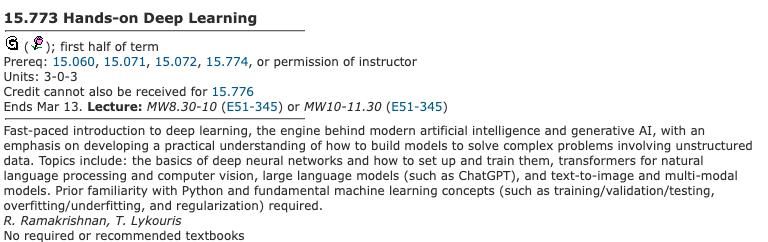

In [ ]:
mit_course_data[mit_course_data.course_name == '15.773 Hands-on Deep Learning']

,course_name,description,text
336,15.773 Hands-on Deep Learning,"Graduate Spring MW8.30-10 MW10-11.30 R. Ramakrishnan, T. Lykouris ( ); first half of term Prereq: , , , , or permission of instructor Units: 3-0-3 Credit cannot also be received for Ends Mar 13. ( ) or ( ) Fast-paced introduction to deep learning, the engine behind modern artificial intelligence and generative AI, with an emphasis on developing a practical understanding of how to build ...","15.773 Hands-on Deep Learning Course Info: Graduate Spring MW8.30-10 MW10-11.30 R. Ramakrishnan, T. Lykouris ( ); first half of term Prereq: , , , , or permission of instructor Units: 3-0-3 Credit cannot also be received for Ends Mar 13. ( ) or ( ) Fast-paced introduction to deep learning, the engine behind modern artificial intelligence and generative AI, with an emphasis on developing..."


# Retrieval Augmented Generation (RAG)

We will now develop a RAG approach, very similar to what we did in Lecture 10.



The first question: what is a natural choice for a **chunk**? Should it be paragraph, section etc.?

For our problem, each course text description is a very natural choice for a chunk, since that contains all the info needed to answer questions about that course. For each row, we will just grab the `text` field and run it through the embedding model to get contextual embeddings.

Like we did in lecture, we will first define a function to calculate the embedding of any chunk using the `text-embedding-ada-002` model and then calculate the embedding of every course `text`.

In [ ]:
def get_embedding(text: str, model: str=EMBEDDING_MODEL) -> list[float]:
    result = client.embeddings.create(
      model=EMBEDDING_MODEL,  # which embedding model we want to use
      input=text,            # feed in the text for which you want to calc the embedding
    )
    return result.data[0].embedding

def compute_doc_embeddings_from_column(df: pd.DataFrame, column_name: str) -> dict[tuple[str, str], list[float]]:
    """
    Takes a column of df and create an embedding for each row in the dataframe using the OpenAI Embeddings API.

    Return a dictionary that maps between each embedding vector and the index of the row that it corresponds to.
    """
    return {
        idx: get_embedding(r[column_name]) for idx, r in df.iterrows()
    }

mit_embeddings = compute_doc_embeddings_from_column(mit_course_data, 'text')
mit_course_data['embeddings'] = mit_embeddings
mit_course_data.head()

,course_name,description,text,embeddings
0,15.000 Explorations in Management,"Undergrad Fall J. Orlin ( ) Prereq: None Units: 2-0-1 [P/D/F] Broad introduction to the various aspects of management including analytics, accounting and finance, operations, marketing, entrepreneurship and leadership, organizations, economics, systems dynamics, and negotiation and communication. Introduces the field of management through a variety of experiences as well as discussions led ...","15.000 Explorations in Management Course Info: Undergrad Fall J. Orlin ( ) Prereq: None Units: 2-0-1 [P/D/F] Broad introduction to the various aspects of management including analytics, accounting and finance, operations, marketing, entrepreneurship and leadership, organizations, economics, systems dynamics, and negotiation and communication. Introduces the field of management through a var...","[-0.06243009492754936, 0.04580080136656761, 0.044165972620248795, -0.040308792144060135, -0.02615729160606861, -0.013033943250775337, 0.0019222032278776169, 0.014751791954040527, -0.002113784896209836, -0.0014703896595165133, 0.042275700718164444, -0.041432738304138184, -0.02886497974395752, -0.0013618266675621271, 0.035480935126543045, 0.021521013230085373, -0.018085313960909843, -0.018838869..."
1,15.002 Leadership Challenges for an Inclusive World,"Graduate Fall Spring TBA Consult: Sloan Educational Services Consult: Sloan Educational Services ( , ) Prereq: None Units arranged [P/D/F] Units assigned to MBA students upon completion. Restricted to Sloan MBA students. Fall: Spring: No textbook information available","15.002 Leadership Challenges for an Inclusive World Course Info: Graduate Fall Spring TBA Consult: Sloan Educational Services Consult: Sloan Educational Services ( , ) Prereq: None Units arranged [P/D/F] Units assigned to MBA students upon completion. Restricted to Sloan MBA students. Fall: Spring: No textbook information available","[-0.06742530316114426, 0.017512723803520203, 0.07514455169439316, 0.0016557663911953568, -0.019193105399608612, -0.01772277243435383, 0.006111074239015579, 0.011618261225521564, -0.012130252085626125, 0.001801815116778016, 0.014401393011212349, -0.030588191002607346, -0.03313501924276352, 0.0020512468181550503, -0.007016904652118683, 0.07650986313819885, -0.014795232564210892, -0.0019790427759..."
2,15.003 Analytics Tools,"Graduate Fall IAP M. Li M. Li ( , ) Prereq: None Units: 2-0-1 [P/D/F] Units assigned to Master of Business Analytics students upon completion of the Analytics Tools requirement. Restricted to Master of Business Analytics students. Fall: IAP: No textbook information available","15.003 Analytics Tools Course Info: Graduate Fall IAP M. Li M. Li ( , ) Prereq: None Units: 2-0-1 [P/D/F] Units assigned to Master of Business Analytics students upon completion of the Analytics Tools requirement. Restricted to Master of Business Analytics students. Fall: IAP: No textbook information available","[-0.022731944918632507, 0.07042932510375977, 0.030822135508060455, -0.03868897631764412, -0.047871094197034836, -0.06640904396772385, -0.02613181062042713, -0.026801858097314835, 0.029308326542377472, -0.01737157441675663, 0.03945828974246979, -0.030474703758955002, -0.02891126275062561, -0.015162902884185314, 0.04062466695904732, 0.0496082529425621, -0.018786117434501648, -0.02687630616128444..."
3,15.004 Programming for Finance Professionals,"Graduate Fall Summer B. Vartak B. Vartak ( , ) Prereq: None Units: 1-0-0 [P/D/F] Two-day accelerated course with supplemental recitations designed to develop skills in applying basic methods from the programming language Python (with additional references from R) to financial problems. Topics include programming basics in Python, data manipulation, visualization and reporting and an overvie...","15.004 Programming for Finance Professionals Course Info: Graduate Fall Summer B. Vartak B. Vartak ( , ) Prereq: None Units: 1-0-0 [P/D/F] Two-day accelerated course with supplemental recitation

So we have a custom data-set split into chunks, and embedding vectors calculated for each. We also have a function that can calculate the embedding for any question.

Next we will use these embeddings to answer our users' questions.


Each time we receive a question

* We calculate an embedding vector for the question with the `get_embedding` funtion we defined above.
* For each chunk in our custom dataset, we calculate the cosine similarity between that chunk's embedding vector and the question's embedding vector
* We rank the sections from most-cosine-similar to the question to least-cosine-similar

We first define a couple of helper functions.

In [ ]:
def cosine_sim(x,y):
  return np.dot(x,y)/np.sqrt(np.dot(x,x) * np.dot(y,y))

In [ ]:
from IPython import embed

# search function
def strings_ranked_by_relatedness(
    query: str,
    df: pd.DataFrame,
    top_n: int = 100
) -> tuple[list[str], list[float]]:

    """Returns a list of strings and relatednesses, sorted from most related to least."""

    query_embedding = get_embedding(query) # bug fixed

    strings_and_relatednesses = [
        (row["text"], cosine_sim(query_embedding, row["embeddings"]))
        for i, row in df.iterrows()
    ]
    strings_and_relatednesses.sort(key=lambda x: x[1], reverse=True)
    strings, relatednesses = zip(*strings_and_relatednesses)
    return strings[:top_n], relatednesses[:top_n]

Let's examine this function to see what it pulls up as documents most similar to the query string "deep learning"

In [ ]:
strings, relatednesses = strings_ranked_by_relatedness("Who teaches hands-on deep learning?", mit_course_data, top_n=5)
for string, relatedness in zip(strings, relatednesses):
    print(f"***{relatedness=:.3f}***")
    display(string)
    print('\n')

***relatedness=0.681***


'15.773 Hands-on Deep Learning Course Info: Graduate Spring MW8.30-10 MW10-11.30 R. Ramakrishnan, T. Lykouris   ( ); first half of term Prereq: , , , , or permission of instructor Units: 3-0-3 Credit cannot also be received for  Ends Mar 13.  ( ) or ( )    Fast-paced introduction to deep learning, the engine behind modern artificial intelligence and generative AI,\xa0with an emphasis on developing a practical understanding of how to build models to solve complex problems involving unstructured data.\xa0Topics include: the basics of deep neural networks and how to set up and train them, transformers for natural language processing and computer vision, large language models (such as ChatGPT), and text-to-image and multi-modal models. Prior familiarity with Python and fundamental machine learning concepts (such as training/validation/testing, overfitting/underfitting, and regularization) required. No required or recommended textbooks '



***relatedness=0.640***


'15.776 Intensive Hands-on Deep Learning\n(New) Course Info: Graduate Fall Coreq: 15.072 V. Farias   ( ); second half of term Prereq: None. ; or permission of instructor Units: 3-0-3 Credit cannot also be received for   Fast-paced introduction to deep learning, the engine behind modern artificial intelligence, with an emphasis on developing a practical understanding of how to build models to solve complex problems involving unstructured data. Rapid introduction to deep neural networks and their training. Emphasis on language models, focused on masked and generative modeling and vision models (using diffusions and transformers).\xa0Model adaptation via fine-tuning, RL-based training (eg., RLHF, GRPO, etc.). System design concepts\xa0including retrieval augmented generation and\xa0agentic system design.\xa0Prior familiarity with Python and fundamental machine learning concepts (such as training/validation/testing, overfitting/underfitting, and regularization) required. Preference to Sloa



***relatedness=0.424***


'15.355 Engine Lab: Building & Scaling Deep Tech Ventures Course Info: Graduate Spring W2.30-5.30 F. Murray   ( ) Prereq: Permission of instructor Units: 3-0-6  ( )    Provides insights, tools, and strategic frameworks for students focused on founding, joining, and investing in deep tech ventures (DTVs) at early and growth stages (i.e. Seed, Series A-C). Tools unique to DTVs will include techno-economic models (TEAs), technology roadmaps, \xa0milestone-based planning and first-of-a-kind funding structures. Relevant technologies covered will vary each semester, but include e.g. quantum, energy storage, semiconductors, space, rDNA (with end uses including defense/security, climate and health sectors). The course includes a hands-on action-learning project with a local DTV, live cases and engagement with US and international deep tech venture capital providers. The class takes a deliberately international perspective including comparative understanding of deep tech ecosystems in the US, E



***relatedness=0.422***


'15.095 Machine Learning Under a Modern Optimization Lens Course Info: Graduate Fall D. Bertsimas   ( ) Prereq: , , or permission of instructor Units: 3-1-8  Develops algorithms for central problems in machine learning from a modern optimization perspective. Topics include sparse, convex, robust and median regression; an algorithmic framework for regression; optimal classification and regression trees, and their relationship with neural networks; how to transform predictive algorithms to prescriptive algorithms; optimal prescriptive trees; and robust classification.\xa0 Also covers design of experiments, missing data imputations, mixture of Gaussian models, exact bootstrap, and sparse matrix estimation, including principal component analysis, factor analysis, inverse co-variance matrix estimation, and matrix completion.  '



***relatedness=0.410***


'15.076 Analytics for a Better World Course Info: Undergrad Spring Institute Lab MW11.30-1 F11.30 +final D. Den Hertog   ( )  Prereq:  Units: 4-0-8  ( )  ( )    Introduces predictive and prescriptive analytics methods to solve problems that contribute to the welfare of society. Emphasis on using machine learning and optimization methods in innovative ways using real world data. Methods used include: linear and discrete optimization, linear and logistic regression, optimal classification and regression trees, deep learning, random forests, and boosted trees. Projects utilize Julia, Jump, and Tensor Flow. Assessment based on projects, including a capstone project. Restricted to undergraduates.  '

Now, we write a function `query_messsage` which constructs a prompt for GPT given a query. The function produces a query in the following format.

```
Use the below course catalog from MIT Sloan to answer the subsequent questions

Course description section: ...

Course description section: ...

...

Course description section: ...

Question: What are some courses in deep learning at MIT Sloan?
```

Note that the prompt starts with a sentence asking GPT to use the below course catalog. It then proceeds to list courses the are relevant (using the embedding and cosine similarity). Finally, the question we are interested in is written.

In [ ]:
import tiktoken  # for counting tokens

def num_tokens(text: str, model: str = GPT_MODEL) -> int:
    """Return the number of tokens in a string."""
    encoding = tiktoken.encoding_for_model(model)
    return len(encoding.encode(text))

def query_message(
    query: str,
    df: pd.DataFrame,
    model: str,
    token_budget: int
) -> str:
    """Return a message for GPT, with relevant source texts pulled from a dataframe."""
    strings, relatednesses = strings_ranked_by_relatedness(query, df)
    message = "Use the below course catalog from MIT Sloan to answer the subsequent question. "

    question = f"\n\nQuestion: {query}"

    for string in strings:
        next_article = f'\nCourse description section: {string}\n'
        if (
            num_tokens(message + next_article + question, model=model)
            > token_budget
        ):
            break
        else:
            message += next_article
    return message + question

Query message first begins with the `HEADER` and then pulls the related articles sorted in descending order of similarity to the query. We then add these articles to the query until the token budget is consumed (we use a token budget of 3700 tokens just like we did in the Lecture 10 colab).


In [ ]:
query = query_message("'What course at MIT sloan are about deep learning?", mit_course_data, GPT_MODEL, 3700)

print(query)

Use the below course catalog from MIT Sloan to answer the subsequent question. 
Course description section: 15.776 Intensive Hands-on Deep Learning
(New) Course Info: Graduate Fall Coreq: 15.072 V. Farias   ( ); second half of term Prereq: None. ; or permission of instructor Units: 3-0-3 Credit cannot also be received for   Fast-paced introduction to deep learning, the engine behind modern artificial intelligence, with an emphasis on developing a practical understanding of how to build models to solve complex problems involving unstructured data. Rapid introduction to deep neural networks and their training. Emphasis on language models, focused on masked and generative modeling and vision models (using diffusions and transformers). Model adaptation via fine-tuning, RL-based training (eg., RLHF, GRPO, etc.). System design concepts including retrieval augmented generation and agentic system design. Prior familiarity with Python and fundamental machine learning concepts (such as training/

Now let's write a little function which will pass the above prompt to GPT for a response.


In [ ]:
def ask(
    query: str,
    df: pd.DataFrame = mit_course_data,
    model: str = GPT_MODEL,
    token_budget: int = 4096 - 500,
) -> str:
    """Answers a query using GPT and a dataframe of relevant texts and embeddings."""
    message = query_message(query, df, model=model, token_budget=token_budget)

    messages = [
        {"role": "system", "content": "You answer questions about MIT Sloan Courses."},
        {"role": "user", "content": message},
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0
    )
    response_message = response.choices[0].message.content
    return response_message

We can finally answer the user's query!

In [ ]:
print(ask(query))

At MIT Sloan, the following courses are focused on deep learning:

1. **15.776 Intensive Hands-on Deep Learning**
   - A fast-paced introduction to deep learning with an emphasis on building models to solve complex problems involving unstructured data. Topics include deep neural networks, language models, vision models, and system design concepts.

2. **15.773 Hands-on Deep Learning**
   - This course provides a practical understanding of deep learning, covering topics such as deep neural networks, transformers for natural language processing and computer vision, and large language models.

3. **15.573 Generative AI for Managers**
   - While not exclusively about deep learning, this course prepares students to navigate and lead in the era of generative AI, which includes core technologies like large language models and image generation.

These courses emphasize practical applications and understanding of deep learning techniques and their implications in various fields.


In [ ]:
print(ask('What are some courses at MIT Sloan on operations research or operations management? Please list them with their instructors.'))

Here are some courses at MIT Sloan related to operations research or operations management, along with their instructors:

1. **15.764[J] The Theory of Operations Management**
   - Instructor: N. Trichakis

2. **15.7611 Introduction to Operations Management**
   - Instructors: A. Aouad, D. Freund

3. **15.734 Introduction to Operations Management**
   - Instructor: R. Levi

4. **15.761 Introduction to Operations Management**
   - Instructors: R. Levi, A. Aouad, D. Freund, S. Willems

5. **15.774 The Analytics of Operations Management**
   - Instructor: M. Fazel Zarandi

6. **15.778 Introduction to Operations Management**
   - Instructor: V. Farias

7. **15.769 Operations Strategy**
   - Instructor: Y. Karen Zheng

8. **15.784 Operations Laboratory**
   - Instructor: T. Roemer

9. **15.799 Workshop in Operations Management**
   - Instructors: D. Freund, T. Lykouris

10. **15.780 Analytics of Operations Management**
    - Instructor: M. Fazel Zarandi

11. **15.090 Common Experience in Op

In [ ]:
print(ask('Which courses are taught by R. Ramakrishnan? Please list them and the semester they are offered in.'))

R. Ramakrishnan teaches the following courses:

1. **15.060 Data, Models, and Decisions**
   - Semester: Fall, Summer

2. **15.773 Hands-on Deep Learning**
   - Semester: Spring

These are the courses associated with R. Ramakrishnan as per the provided course catalog.


In [ ]:
print(ask('Are there any co-requisites to Hands-On Deep Learning?'))

Yes, the course 15.776 Intensive Hands-on Deep Learning has a co-requisite of 15.072. However, the course 15.773 Hands-on Deep Learning does not list any co-requisites.


# RAG + Few Shot Prompting

Let's look at the following question.

In [ ]:
print(ask('How many units is 15.773 Hands-on Deep Learning?'))

The course 15.773 Hands-on Deep Learning is worth 3-0-3 units.


Hmm ... this is not quite correct. 15.773 is a 6-unit class. The reason GPT cannot answer this correctly is that in the course catalog, the Units is given as three numbers: `3-0-3`. GPT does not know that the total number of units should be the sum of these three numbers. How can we tell GPT this?

Let's add some **few-shot learning** i.e., let's provide a couple of examples of how to do this in the prompt itself!

We will augment the prompt from above as follows:


```
Use the below course catalog from MIT Sloan to answer the subsequent questions.
If the question pertains to the number of credits or units in a course,
you need to add the numbers in the course description.
For example, if the units are 3-0-6, you should add 3 + 0 + 6 and provide 9
as the answer. If the units are 1-2-3, you should provide 6 as the answer.

... (the rest of the prompt is unchanged from before)

```



In [ ]:
def query_message_with_units(
    query: str,
    df: pd.DataFrame,
    model: str,
    token_budget: int
) -> str:
    strings, relatednesses = strings_ranked_by_relatedness(query, df)
    message = "Use the below course catalog from MIT Sloan to answer the subsequent question.\n \
    If the question pertains to the number of credits or units in a course, you need \
    to add the numbers in the course description. For example, if the units are \
    3-0-6, you should add 3 + 0 + 6 and provide 9 as the answer. \
    If the units are 1-2-3, you should provide 6 as the answer."

    question = f"\n\nQuestion: {query}"

    for string in strings:
        next_article = f'\n\nCourse description section:\n"""\n{string}\n"""'
        if (
            num_tokens(message + next_article + question, model=model)
            > token_budget
        ):
            break
        else:
            message += next_article
    return message + question

def ask_with_units(
    query: str,
    df: pd.DataFrame = mit_course_data,
    model: str = GPT_MODEL,
    token_budget: int = 4096 - 500,
) -> str:
    """Answers a query using GPT and a dataframe of relevant texts and embeddings."""
    message = query_message_with_units(query, df, model=model, token_budget=token_budget)

    messages = [
        {"role": "system", "content": "You answer questions about MIT Sloan Courses."},
        {"role": "user", "content": message},
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=0
    )
    response_message = response.choices[0].message.content
    return response_message

In [ ]:
print(ask_with_units('For each of the classes The Analytics Edge, Data Models \
 and Decisions and Hands-On Deep Learning, please list the number of units'))

Here are the number of units for each of the specified classes:

1. **The Analytics Edge (15.0711)**: 4-0-8 → 4 + 0 + 8 = **12 units**
2. **Data, Models, and Decisions (15.060)**: 3-0-6 → 3 + 0 + 6 = **9 units**
3. **Hands-On Deep Learning (15.773)**: 3-0-3 → 3 + 0 + 3 = **6 units**
